# Overfeeding

In [ ]:
import datetime
import pingouin as pg
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
sns.set_theme(context='talk', style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = 10, 7
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['figure.titlesize'] = 32
plt.rcParams['axes.titlesize'] = 32
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['figure.autolayout'] = 'true'
plt.rcParams['figure.frameon'] = 'false'
plt.rcParams['axes.spines.left'] = 'false'
plt.rcParams['axes.spines.right'] = 'false'
plt.rcParams['axes.spines.top'] = 'false'
plt.rcParams['legend.fancybox'] = 'false'
plt.rcParams['axes.spines.bottom'] = 'false'
plt.rcParams['font.size'] = 20
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
# для графиков, где надо много цветов, юзайте воть:
sns.set_palette(sns.color_palette('deep'))
# а по дефолту воть:
sns.set_palette(sns.color_palette('BuGn_r', n_colors=10)[2::3])
pd.set_option('display.max_columns', 60)

monthly_feeding = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Feeding')
herd_metrics = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Herd maintenance').replace('-', np.nan)
production_indicators = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Dairy indicators').replace('-', np.nan)

herd_metrics["year_month"] = herd_metrics["date"].dt.to_period('M').astype(str)

fad = pd.read_csv("FeedingAndDetails_clear.csv", index_col=0)
fad["Date"] = pd.to_datetime(fad["Date"]) + pd.DateOffset(days=4)
fad["year_month"] = fad["Date"].dt.to_period('M').astype(str)
fad = fad.rename(columns={"FarmName": "farm_name"})

In [2]:
union = pd.merge(production_indicators, herd_metrics, on=['date', 'farm_name', 'prod_farm_name', 'region'], how='inner', suffixes=["_farm", "_herd"])
union['date'] = pd.to_datetime(union['date'])
union = union.drop("farm_type_farm", axis=1)
union.loc[309]["farm_type_herd"] = "ЖК"
union = union.rename(columns={"farm_type_herd": "farm_type"})


In [ ]:
df = fad.copy()

grouped = df.groupby(
    ["Date", "farm_name", "PhysiologicalGroupName", "year_month"]
)["PhysicalWeight_kg"].sum().reset_index()

planned = df[
    ["Date", "farm_name", "PhysiologicalGroupName", "PhysiologicalGroupHeadCount"]
].drop_duplicates()

appetites = planned.groupby(
    ["Date", "farm_name", "PhysiologicalGroupName"]
).agg({
    "PhysiologicalGroupHeadCount": "sum"
}).reset_index().rename(columns={"PhysiologicalGroupHeadCount": "CowCount"})

appetites["CowCount"] = appetites["CowCount"] + 1e-6


date_phy_feeding = pd.merge(
    grouped,
    appetites,
    on=["Date", "farm_name", "PhysiologicalGroupName"],
    how="left"
)
date_phy_feeding["WeightPerCow"] = date_phy_feeding["PhysicalWeight_kg"] / date_phy_feeding["CowCount"]
date_phy_feeding

,Date,farm_name,PhysiologicalGroupName,year_month,PhysicalWeight_kg,CowCount,WeightPerCow
0,2022-01-05,ЖК Добрино,Д0 (Новотельные),2022-01,6076.165,136.000001,44.677683
1,2022-01-05,ЖК Добрино,Д1,2022-01,143544.434,3439.000001,41.740167
2,2022-01-05,ЖК Добрино,Д2,2022-01,16102.000,345.000001,46.672464
3,2022-01-05,ЖК Добрино,Нетели,2022-01,29691.786,1245.000001,23.848824
4,2022-01-05,ЖК Добрино,С1,2022-01,5237.236,172.000001,30.449046
...,...,...,...,...,...,...,...
520366,2025-10-26,РМ Поляна,Т2 (6-8 мес.),2025-10,2773.000,175.000001,15.845714
520367,2025-10-26,РМ Поляна,Т3 (9-12 мес.),2025-10,3196.000,158.000001,20.227848
520368,2025-10-26,РМ Торопово,Нетели,2025-10,26393.897,988.000001,26.714471
520369,2025-10-26,РМ Торопово,Т3 (9-12 мес.),2025-10,2932.291,150.000001,19.548607


In [4]:
monthly_feeding = date_phy_feeding.groupby(
    ['year_month', 'farm_name', 'PhysiologicalGroupName']
).agg({
    'PhysicalWeight_kg': 'sum',
    'CowCount': 'sum',
    'WeightPerCow': 'mean'
}).reset_index()
monthly_feeding

,year_month,farm_name,PhysiologicalGroupName,PhysicalWeight_kg,CowCount,WeightPerCow
0,2022-01,ЖК Добрино,Д0 (Новотельные),127449.683,3185.000021,39.929478
1,2022-01,ЖК Добрино,Д1,4149123.253,112814.000027,37.227009
2,2022-01,ЖК Добрино,Д2,673768.310,15730.000027,43.864834
3,2022-01,ЖК Добрино,Нетели,952518.044,36338.000027,26.316731
4,2022-01,ЖК Добрино,С1,132680.688,4181.000027,31.743763
...,...,...,...,...,...,...
17866,2025-10,ЭФ Родня,Т0 (0-2 мес.),9498.047,1583.000023,6.000030
17867,2025-10,ЭФ Родня,Т1 (3-5 мес.),15589.413,1097.000023,14.264408
17868,2025-10,ЭФ Родня,Т2 (6-8 мес.),24780.955,1278.000023,19.332370
17869,2025-10,ЭФ Родня,Т3 (9-12 мес.),0.000,0.000005,0.000000


In [5]:
def rename_shit(dff):
    """Renames bad PhysiologicalGroupNames"""
    mapping = {'Д0 (Новотельные)': 'Д0', 'Н Нетели': 'Нетели', 'Д3 (Предзапуск)': 'Д3', 'D3': 'Д3', 
               'Нетели 1  группа': 'Нетели','Сух-2': "С2", 'Д-3': 'Д3', 'сух 1': 'С1', 'сух 2': 'С2', 'С1 нетели': 'С1', 
               'С2 нетели': 'С2', 'Н НЕТЕЛИ': 'Нетели', 'Сух 2 Нетели': 'С2', 'С2 Нетели': 'С2'}

    dff["PhysiologicalGroupName"] = dff["PhysiologicalGroupName"].replace(mapping)
    return dff

monthly_feeding = rename_shit(monthly_feeding)
monthly_feeding["PhysiologicalGroupName"].unique()

array(['Д0', 'Д1', 'Д2', 'Нетели', 'С1', 'С2', 'Т0 (0-2 мес.)',
       'Т1 (3-5 мес.)', 'Т2 (6-8 мес.)', 'Т3 (9-12 мес.)', 'Т4 (>1 года)',
       'Б0 (0-2 мес.)', 'Д3', 'Т3 9-12', 'Т0', 'Б3 (9-12 мес.)',
       'Т0 (3-5 мес.)', 'МГ Т3', 'Т2', 'Т2 6-8', 'Т4', 'Т3',
       'Б2 (6-8 мес.)', 'Т4 13-20', 'Б1 (3-5 мес.)', 'Телята СВОД Навесы',
       'Т3 (9-12 мес)', 'МГ Т2', 'МП Коровы', 'МП Нетели',
       'МП БП (бык-производитель)', 'Б4 (>1 года)',
       'МП Б1 (6-12 мес. откорм)', 'МП БР2 (>1 года рем.)',
       'МП Т2 (>1 года откорм)', 'МП БР1 (6-12 мес. рем.)',
       'МП Т0 (0-6 мес.)', 'МП ТР1 (6-12 мес. рем.)', 'Телята домики',
       'МП Б0 (0-6 мес.)', 'МП ТР2 (>1 года рем.)',
       'МП Б2 (>1 года откорм)', 'быки племенные', 'Лошади',
       'Т0 (0-2 мес)', 'Коровы'], dtype=object)

<Axes: xlabel='WeightPerCow', ylabel='Count'>

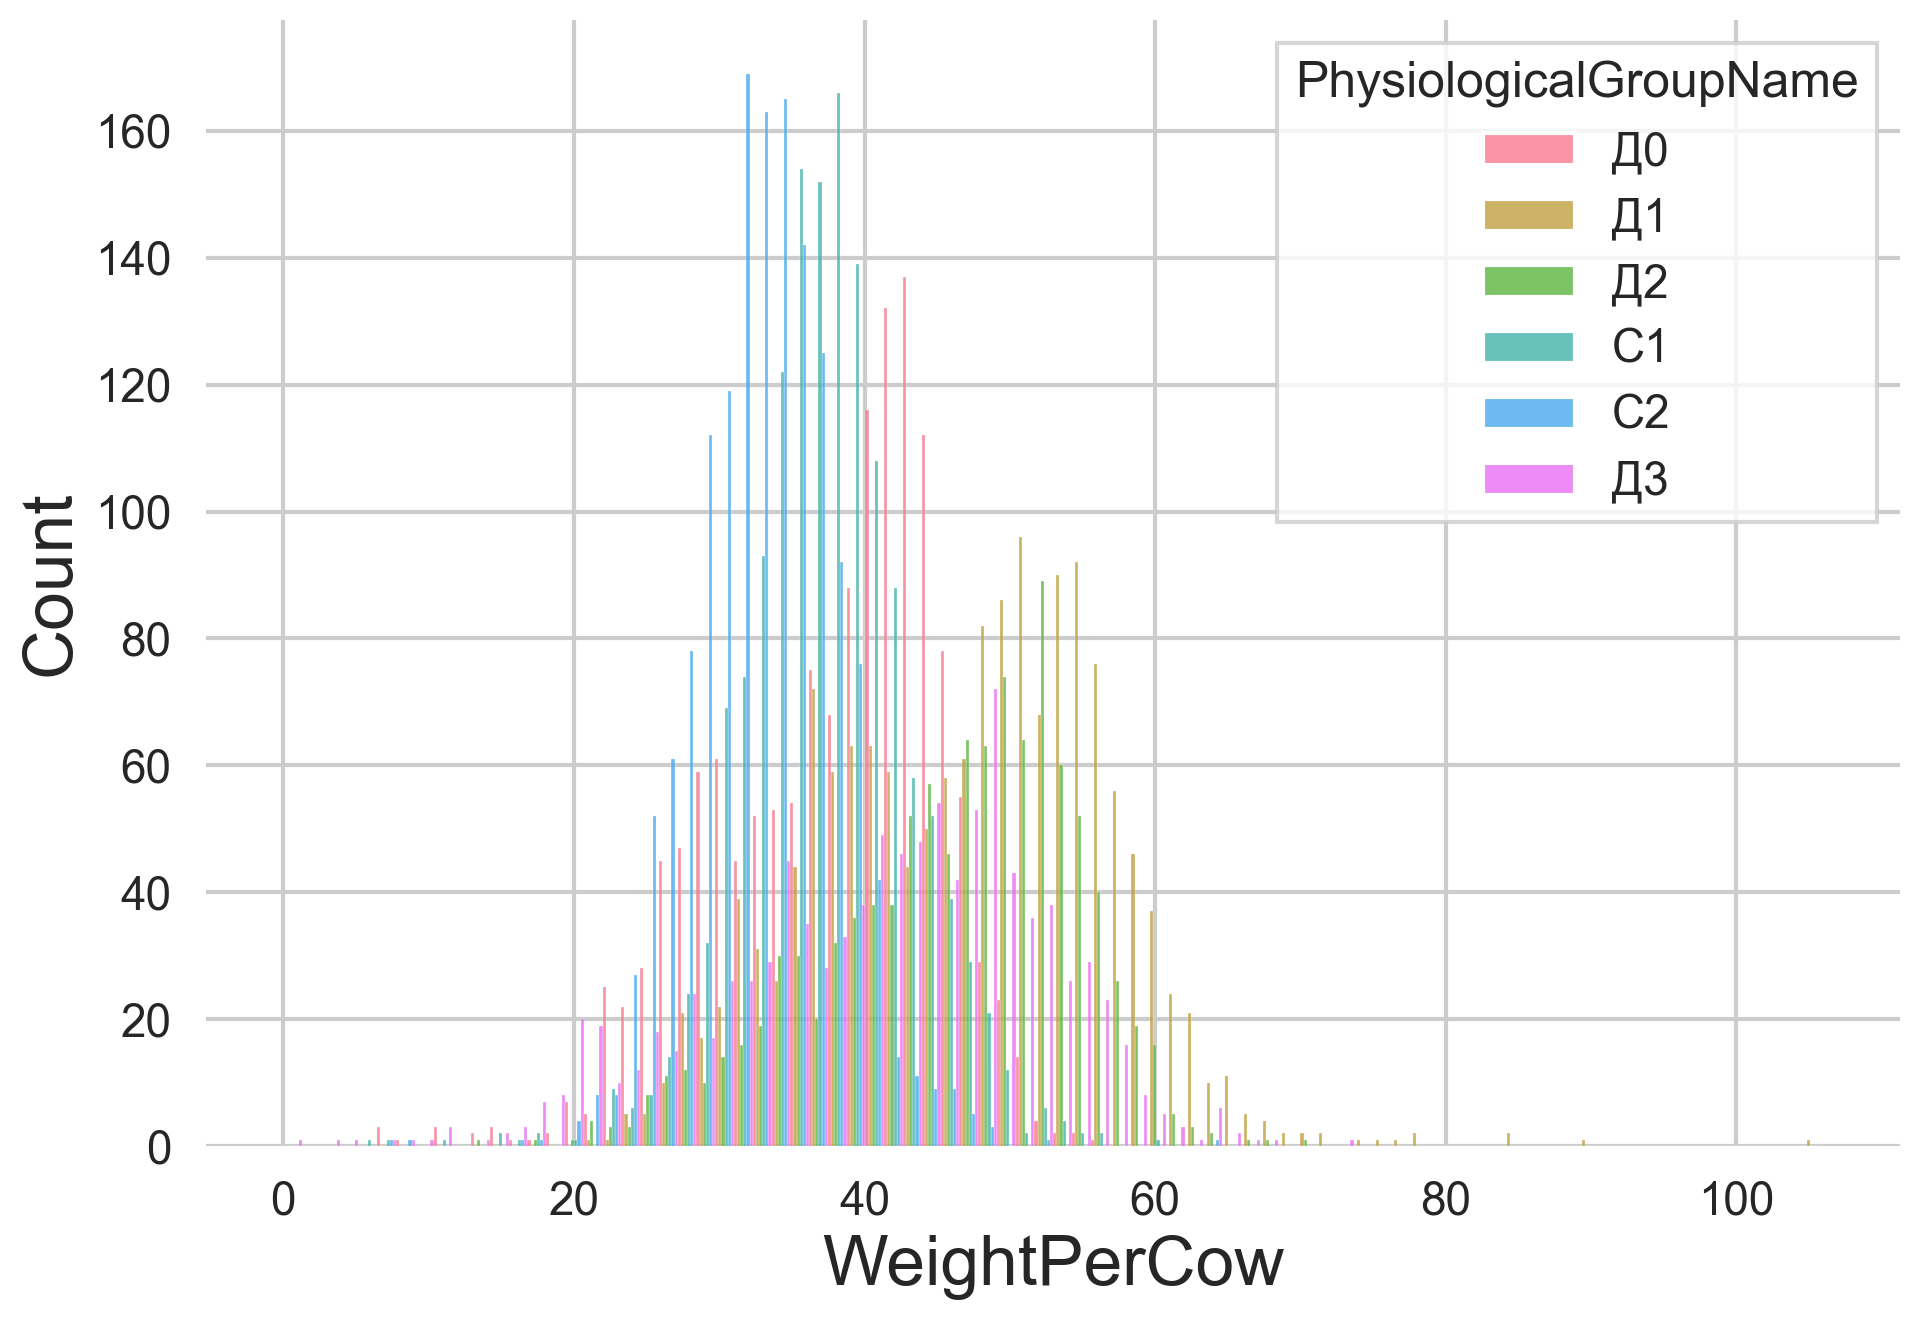

In [6]:
sns.histplot(monthly_feeding[monthly_feeding["PhysiologicalGroupName"].isin(['Д0', 'Д1', 'Д2', 'Д3', 'С1', 'С2'])], x="WeightPerCow", hue="PhysiologicalGroupName", multiple="dodge")

In [7]:
df = pd.merge(herd_metrics, monthly_feeding, on=["farm_name", "year_month"], how="inner")
df

,date,region,prod_farm_name,farm_type,farm_name,ls_capacity,ls_occupancy,forage_cow,milk_cow,dry_cow,milk_marketab_prc,forcow_milk_yeild,forcow_milk_yeild_stand,milk_fat,milk_protein,somatic_cells,bac_contam,cow_retired,cow_lame,cow_mastits,calves,cow_metrit,ph_urine_avr,year_month,PhysiologicalGroupName,PhysicalWeight_kg,CowCount,WeightPerCow
0,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д0,127449.683,3185.000021,39.929478
1,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д1,4149123.253,112814.000027,37.227009
2,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д2,673768.310,15730.000027,43.864834
3,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Нетели,952518.044,36338.000027,26.316731
4,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,С1,132680.688,4181.000027,31.743763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15074,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Д1,3962934.991,93592.000031,42.600275
15075,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Д2,438146.186,7716.000031,57.157341
15076,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Нетели,350374.641,11539.000031,30.449330
15077,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,С1,135351.117,3587.000031,37.718808


<Axes: xlabel='date', ylabel='cow_metrit'>

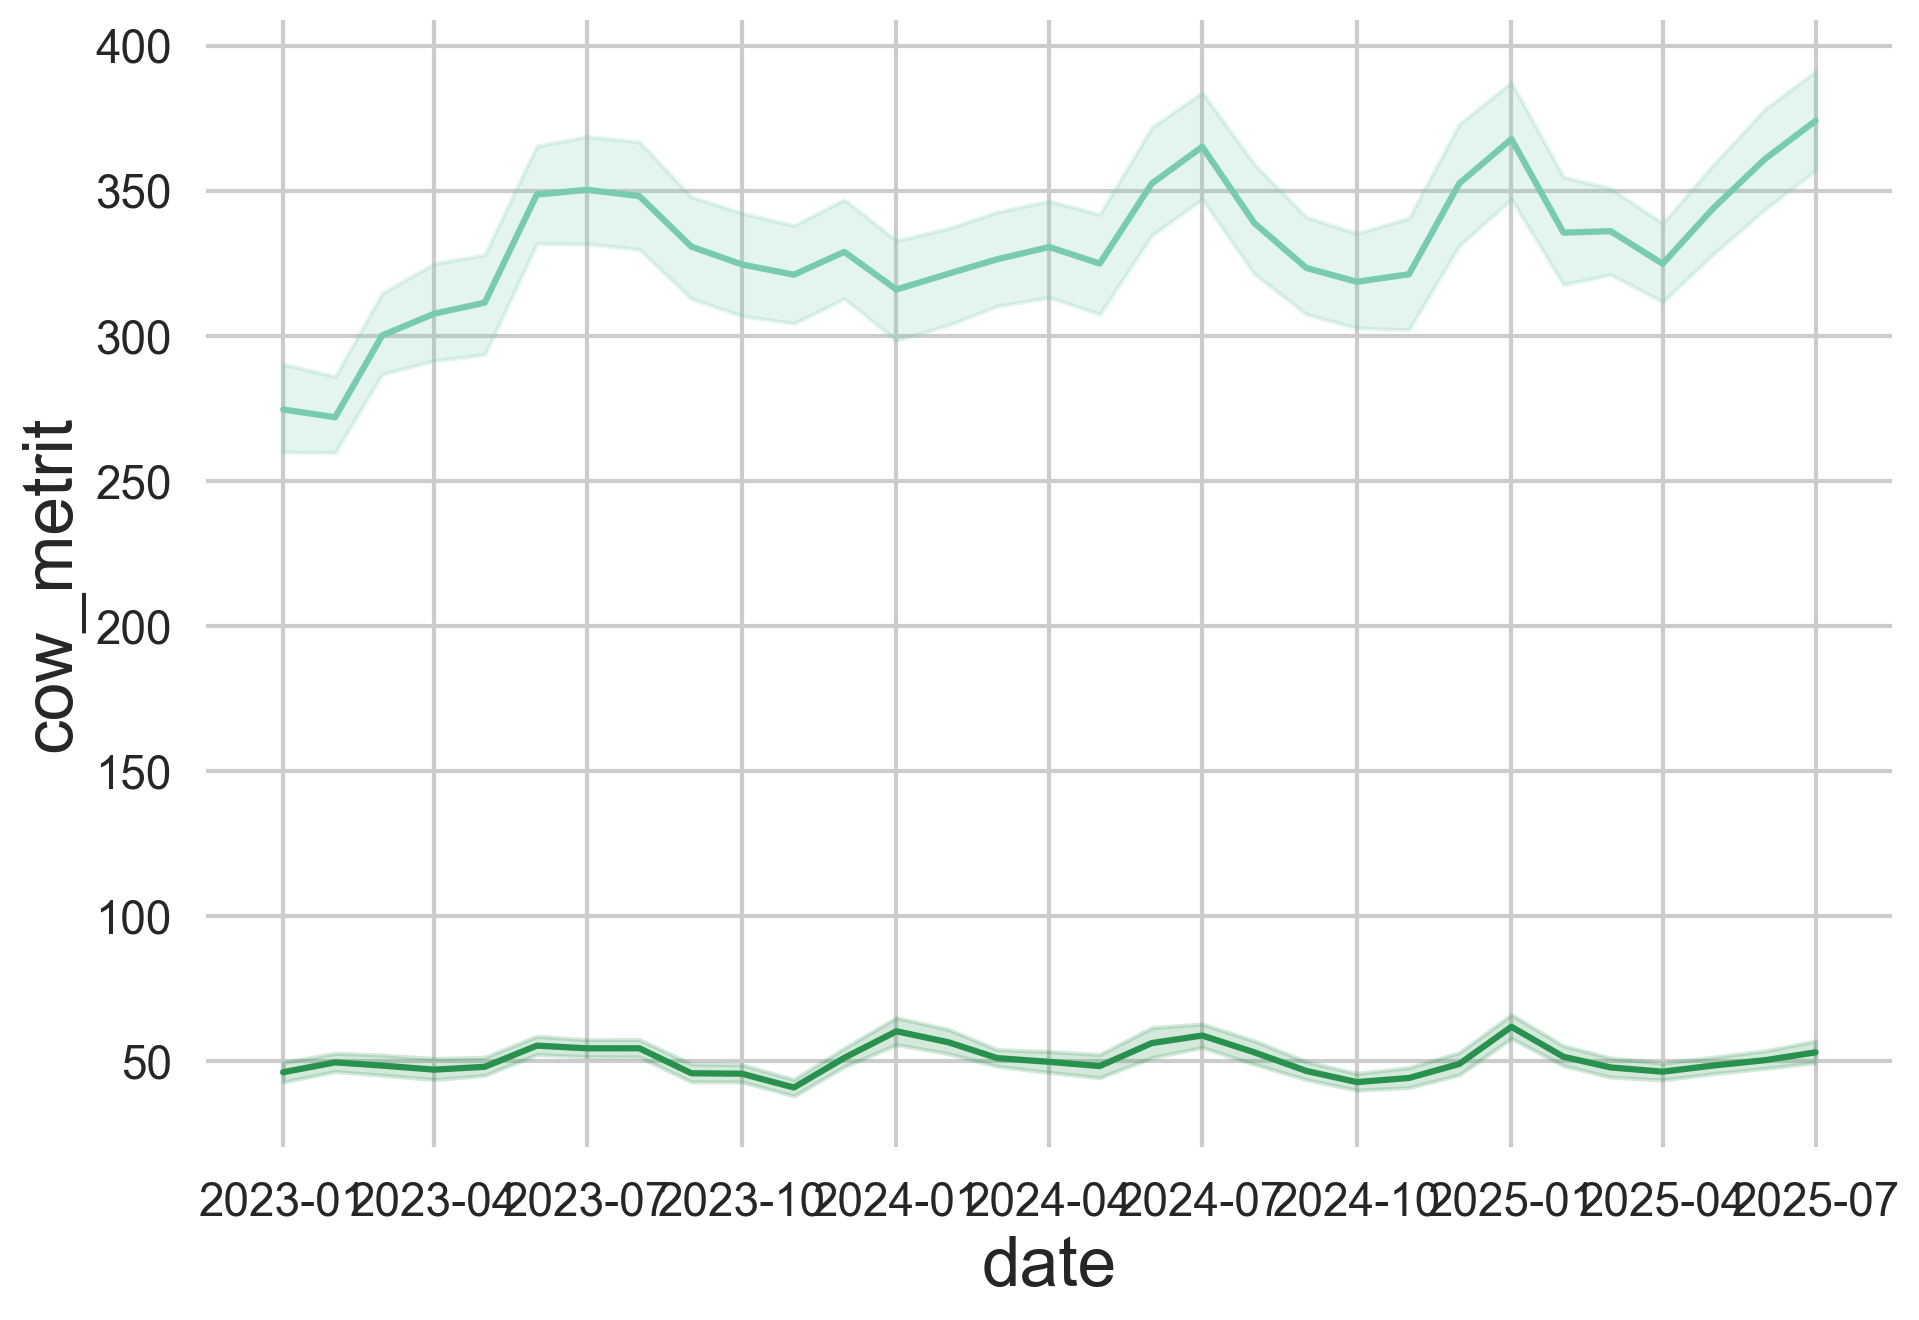

In [8]:
sns.lineplot(df, x="date", y="cow_metrit")
sns.lineplot(df, x="date", y="calves")

In [9]:
df["metrit_rate"] = df["cow_metrit"] / df["calves"]
df

,date,region,prod_farm_name,farm_type,farm_name,ls_capacity,ls_occupancy,forage_cow,milk_cow,dry_cow,milk_marketab_prc,forcow_milk_yeild,forcow_milk_yeild_stand,milk_fat,milk_protein,somatic_cells,bac_contam,cow_retired,cow_lame,cow_mastits,calves,cow_metrit,ph_urine_avr,year_month,PhysiologicalGroupName,PhysicalWeight_kg,CowCount,WeightPerCow,metrit_rate
0,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д0,127449.683,3185.000021,39.929478,NaN
1,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д1,4149123.253,112814.000027,37.227009,NaN
2,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д2,673768.310,15730.000027,43.864834,NaN
3,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Нетели,952518.044,36338.000027,26.316731,NaN
4,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,С1,132680.688,4181.000027,31.743763,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15074,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Д1,3962934.991,93592.000031,42.600275,0.206128
15075,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Д2,438146.186,7716.000031,57.157341,0.206128
15076,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Нетели,350374.641,11539.000031,30.449330,0.206128
15077,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,С1,135351.117,3587.000031,37.718808,0.206128


In [10]:
df[df["metrit_rate"].isna()]

,date,region,prod_farm_name,farm_type,farm_name,ls_capacity,ls_occupancy,forage_cow,milk_cow,dry_cow,milk_marketab_prc,forcow_milk_yeild,forcow_milk_yeild_stand,milk_fat,milk_protein,somatic_cells,bac_contam,cow_retired,cow_lame,cow_mastits,calves,cow_metrit,ph_urine_avr,year_month,PhysiologicalGroupName,PhysicalWeight_kg,CowCount,WeightPerCow,metrit_rate
0,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д0,127449.683,3185.000021,39.929478,NaN
1,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д1,4149123.253,112814.000027,37.227009,NaN
2,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д2,673768.310,15730.000027,43.864834,NaN
3,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Нетели,952518.044,36338.000027,26.316731,NaN
4,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,С1,132680.688,4181.000027,31.743763,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15056,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ,РМ Пеньково,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07,Т0 (0-2 мес.),458049.316,53766.000031,8.520010,NaN
15057,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ,РМ Пеньково,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07,Т1 (3-5 мес.),384949.391,66571.000031,5.803520,NaN
15058,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ,РМ Пеньково,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07,Т2 (6-8 мес.),628113.728,57839.000031,10.924274,NaN
15059,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ,РМ Пеньково,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07,Т3 (9-12 мес.),1331669.795,77844.000031,17.642016,NaN


<Axes: xlabel='WeightPerCow', ylabel='Count'>

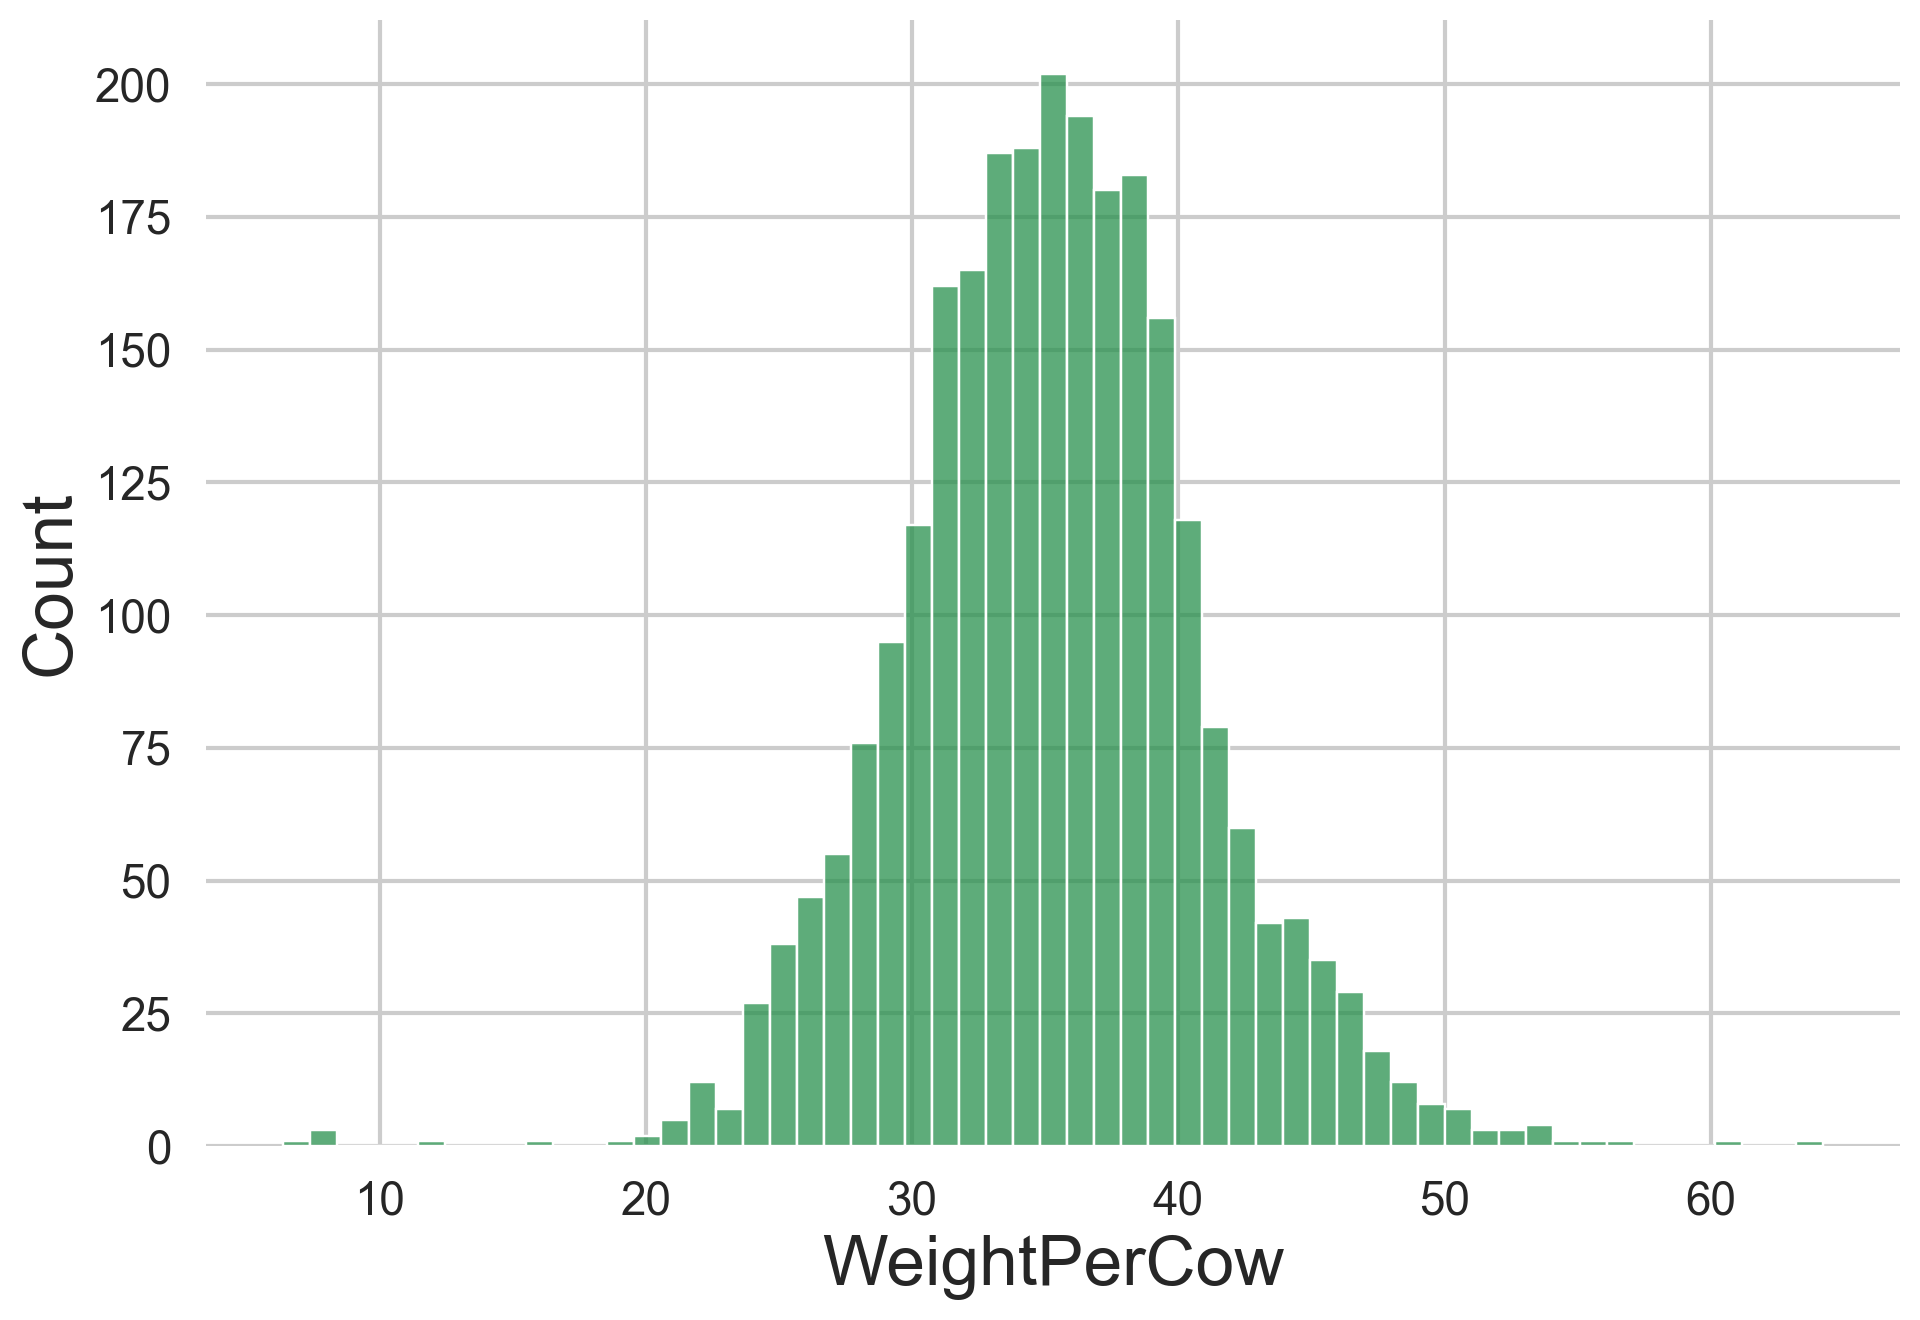

In [11]:
sns.histplot(df[df["PhysiologicalGroupName"].isin(["С1", "С2"])], x="WeightPerCow")

In [12]:
group_c = df[df["PhysiologicalGroupName"].isin(["С1", "С2"])]
group_c = group_c[(~group_c["metrit_rate"].isna()) & (group_c["calves"] != 0)]
group_c

,date,region,prod_farm_name,farm_type,farm_name,ls_capacity,ls_occupancy,forage_cow,milk_cow,dry_cow,milk_marketab_prc,forcow_milk_yeild,forcow_milk_yeild_stand,milk_fat,milk_protein,somatic_cells,bac_contam,cow_retired,cow_lame,cow_mastits,calves,cow_metrit,ph_urine_avr,year_month,PhysiologicalGroupName,PhysicalWeight_kg,CowCount,WeightPerCow,metrit_rate
2237,2023-01-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2900.0,100.448276,2913.0,2611.0,302.0,96.0,31.49,35.1,4.1,3.6,157.6,7.5,45.0,37.0,143,298.0,60.0,6.3,2023-01,С1,181935.160,4324.000031,42.215127,0.201342
2238,2023-01-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2900.0,100.448276,2913.0,2611.0,302.0,96.0,31.49,35.1,4.1,3.6,157.6,7.5,45.0,37.0,143,298.0,60.0,6.3,2023-01,С2,124332.536,3421.000031,36.344459,0.201342
2248,2023-01-01,Воронеж,ЭНА Восток,ЖК,ЖК Верхний Икорец,2900.0,99.172414,2876.0,2534.0,342.0,98.0,31.87,35.2,4.0,3.6,201.0,26.0,43.0,56.0,40,333.0,67.0,6.0,2023-01,С1,195944.266,5144.000031,38.731467,0.201201
2249,2023-01-01,Воронеж,ЭНА Восток,ЖК,ЖК Верхний Икорец,2900.0,99.172414,2876.0,2534.0,342.0,98.0,31.87,35.2,4.0,3.6,201.0,26.0,43.0,56.0,40,333.0,67.0,6.0,2023-01,С2,170910.300,5487.000031,31.218358,0.201201
2257,2023-01-01,Воронеж,ЭНА Восток,ЖК,ЖК Петропавловка,2900.0,99.000000,2863.0,2572.0,291.0,99.0,32.44,34.2,3.8,3.4,152.0,13.0,58.0,22.0,56,237.0,24.0,6.4,2023-01,С1,189074.854,4713.000031,40.365128,0.101266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15052,2025-07-01,Сибирь,Сибирская Нива Маслянино,ЖК,ЖК Пеньково,4700.0,99.000000,4666.0,4172.0,494.0,95.0,30.11,31.8,3.9,3.4,114.0,46.0,189.0,305.0,75,843.0,123.0,6.3,2025-07,С2,524422.490,16987.000031,31.208913,0.145907
15066,2025-07-01,Сибирь,Сибирская Нива Черепаново,ЖК,ЖК Огнева Заимка,3550.0,100.000000,3544.0,3141.0,403.0,94.0,34.95,36.0,3.8,3.3,91.0,38.0,115.0,124.0,47,514.0,131.0,6.5,2025-07,С1,269374.993,6231.000031,43.239221,0.254864
15067,2025-07-01,Сибирь,Сибирская Нива Черепаново,ЖК,ЖК Огнева Заимка,3550.0,100.000000,3544.0,3141.0,403.0,94.0,34.95,36.0,3.8,3.3,91.0,38.0,115.0,124.0,47,514.0,131.0,6.5,2025-07,С2,288011.125,6688.000031,43.050613,0.254864
15077,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.40,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,С1,135351.117,3587.000031,37.718808,0.206128


In [13]:
group_c['overfed'] = group_c['WeightPerCow'] > 43
group_c = group_c[group_c["metrit_rate"] < 4]

<Axes: xlabel='overfed', ylabel='metrit_rate'>

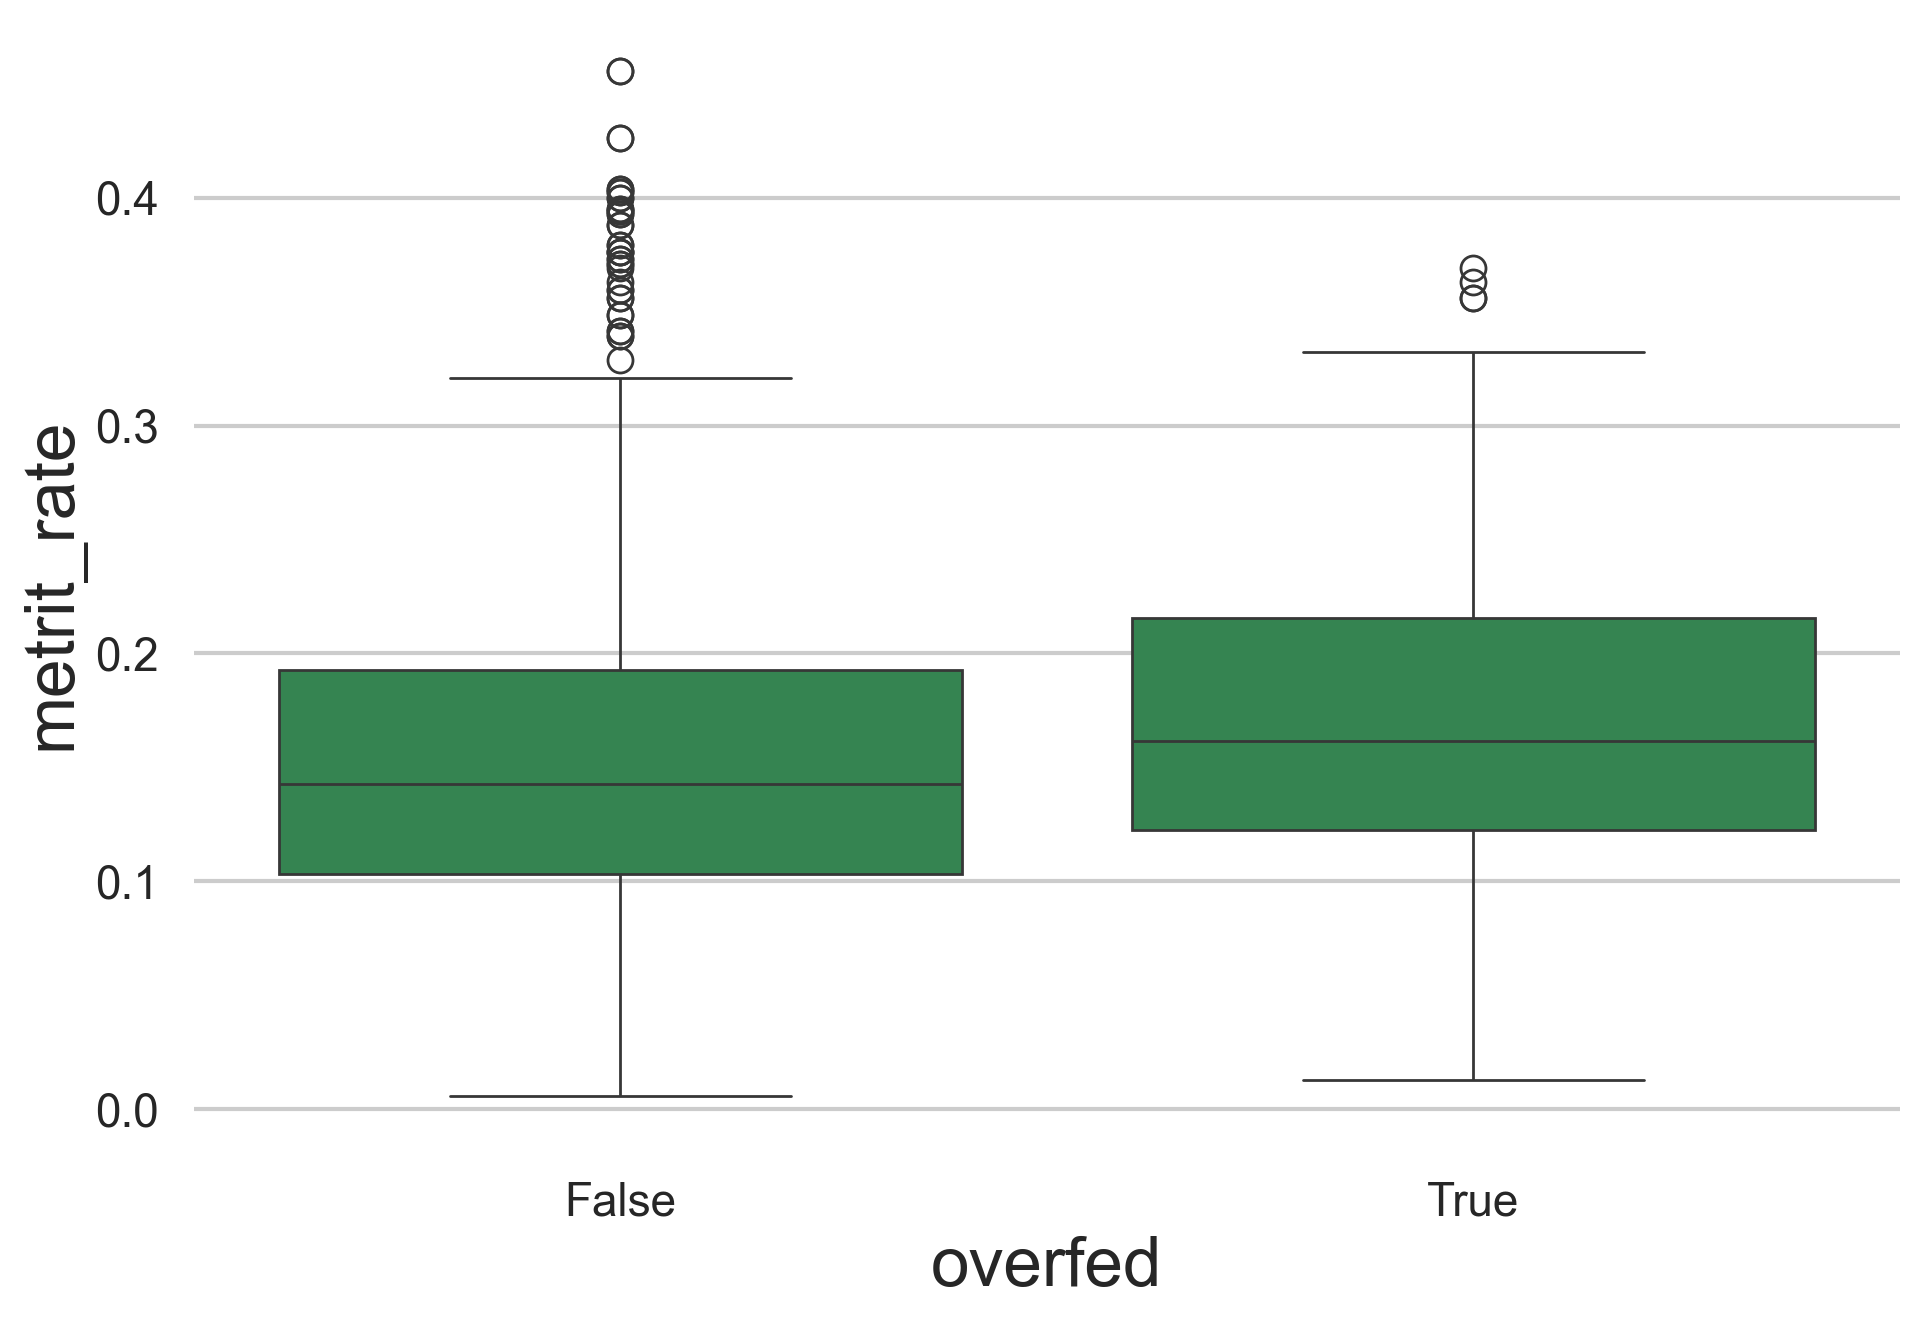

In [14]:
sns.boxplot(group_c, x="overfed", y="metrit_rate")

In [15]:
pg.ttest(group_c[group_c["overfed"] == 0]["metrit_rate"], group_c[group_c["overfed"] == 1]["metrit_rate"], alternative="less")

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-3.720105,214.047404,less,0.000127,"[-inf, -0.01]",0.29356,148.189,0.983984
